Initializing Financial Inclusion Forecaster...
Forecaster initialized with:
  - 49 observations
  - 12 events
  - 2 impact links
  - 3 targets

FORECASTING FINANCIAL INCLUSION INDICATORS

Forecasting: ACC_OWNERSHIP
Prepared time series for ACC_OWNERSHIP: 4 points from 2014 to 2024
Considering 4 future events in forecast
Prepared time series for ACC_OWNERSHIP: 4 points from 2014 to 2024
Prepared time series for ACC_OWNERSHIP: 4 points from 2014 to 2024
Considering 4 future events in forecast
Prepared time series for ACC_OWNERSHIP: 4 points from 2014 to 2024
Prepared time series for ACC_OWNERSHIP: 4 points from 2014 to 2024
Considering 4 future events in forecast
Prepared time series for ACC_OWNERSHIP: 4 points from 2014 to 2024
2025: No base forecast available
2026: No base forecast available
2027: No base forecast available

Forecasting: ACC_MM_ACCOUNT
Prepared time series for ACC_MM_ACCOUNT: 2 points from 2021 to 2024
Considering 4 future events in forecast
Prepared time series for AC

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Prepared time series for ACC_MM_ACCOUNT: 2 points from 2021 to 2024
2025: No base forecast available
2026: No base forecast available
2027: No base forecast available

Forecasting: USG_DIGITAL_PAYMENT
Considering 4 future events in forecast
Considering 4 future events in forecast
Considering 4 future events in forecast
2025: No base forecast available
2026: No base forecast available
2027: No base forecast available

COMPREHENSIVE FORECAST TABLE
No forecast data generated

CREATING FORECAST VISUALIZATIONS
Prepared time series for ACC_OWNERSHIP: 4 points from 2014 to 2024
Prepared time series for ACC_OWNERSHIP: 4 points from 2014 to 2024
Considering 4 future events in forecast


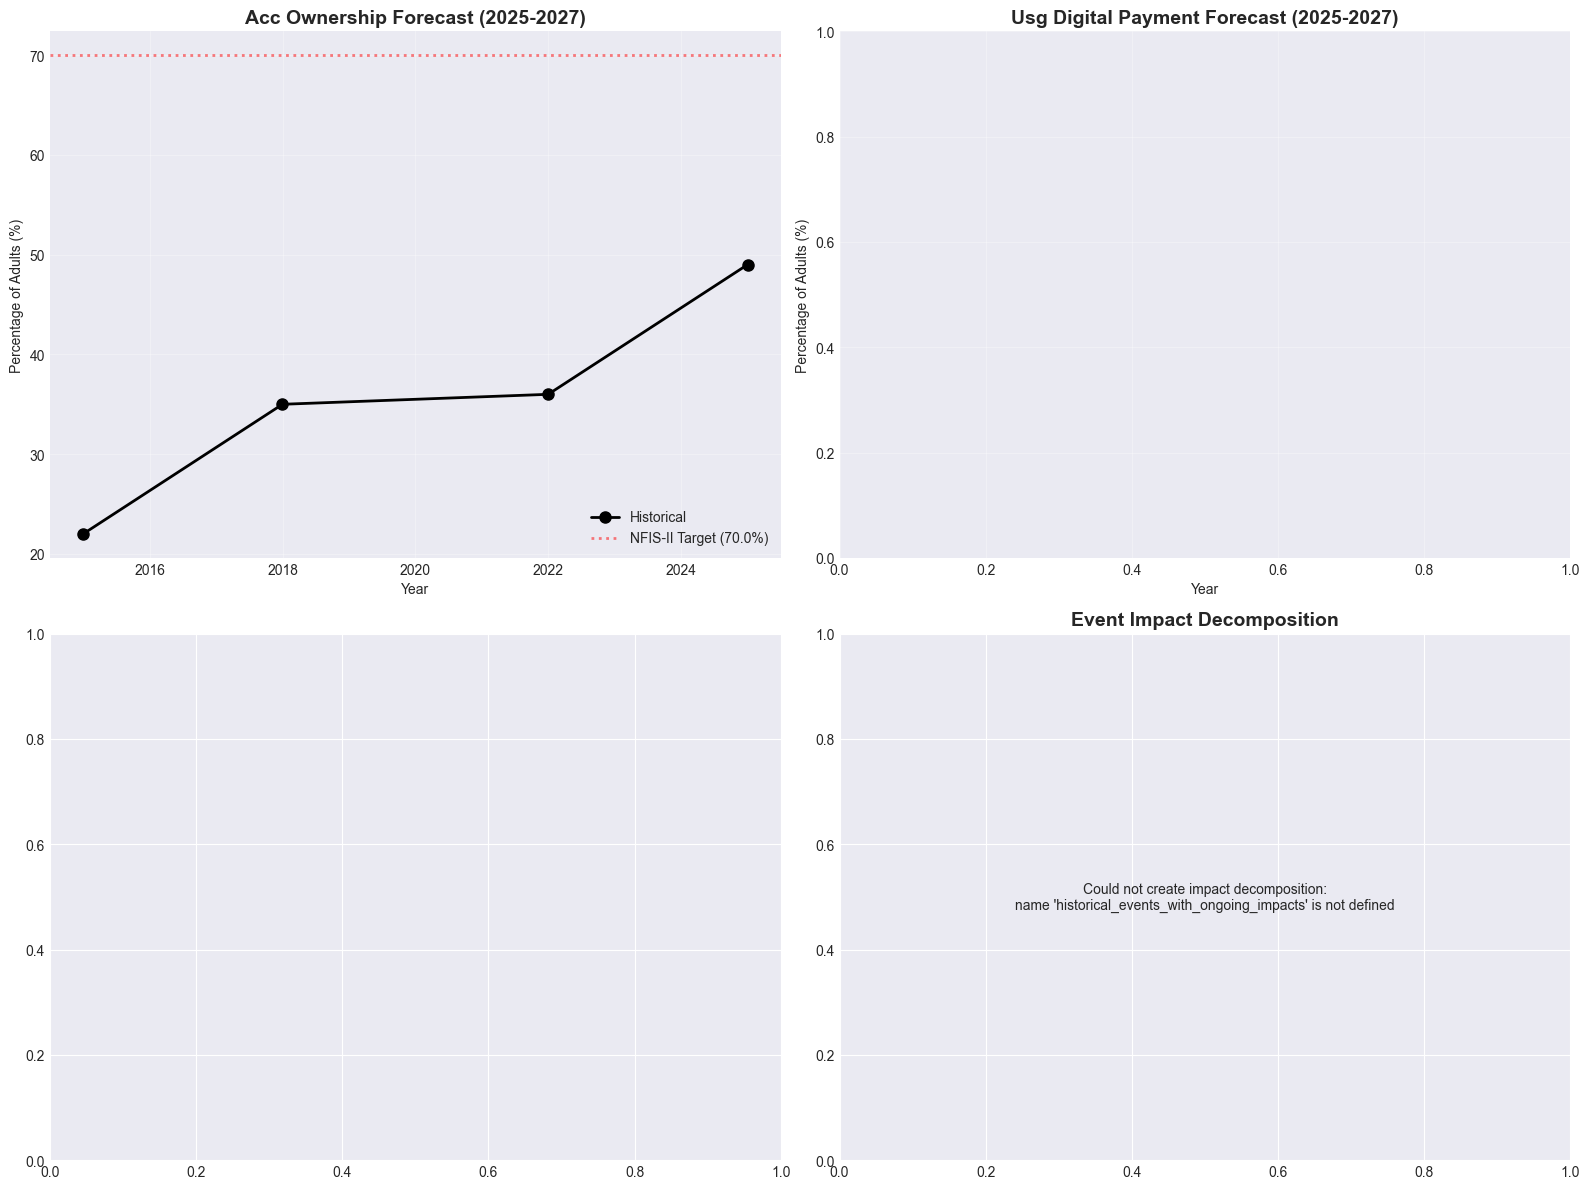

In [6]:
# Task 4: Financial Inclusion Forecasting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import sys
sys.path.append('../src')

from forecasting import FinancialInclusionForecaster

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Initialize forecaster
print("Initializing Financial Inclusion Forecaster...")
forecaster = FinancialInclusionForecaster(r'C:\Users\admin\Ethiopia-fi-forecast\data\processed\enriched_data_fixed.csv')

# 1. Forecast Key Indicators
print("\n" + "="*60)
print("FORECASTING FINANCIAL INCLUSION INDICATORS")
print("="*60)

indicators = ['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'USG_DIGITAL_PAYMENT']
all_forecasts = {}

for indicator in indicators:
    print(f"\n{'='*50}")
    print(f"Forecasting: {indicator}")
    print('='*50)
    
    try:
        # Generate scenario forecasts
        scenarios = forecaster.generate_scenarios(indicator, years_ahead=3)
        
        if scenarios and 'scenarios' in scenarios:
            all_forecasts[indicator] = scenarios
            
            # Print summary safely
            for year_idx, date in enumerate(scenarios['forecast_dates']):
                year = date.year
                base_val = scenarios['scenarios'].get('base', {}).get('adjusted_values', [None]*len(scenarios['forecast_dates']))[year_idx]
                if base_val is None:
                    print(f"{year}: No base forecast available")
                    continue

                if 'range_summary' in scenarios and 'min' in scenarios['range_summary']:
                    min_val = scenarios['range_summary']['min'][year_idx]
                    max_val = scenarios['range_summary']['max'][year_idx]
                    print(f"{year}: {base_val:.1f}% (Range: {min_val:.1f}% - {max_val:.1f}%)")
                else:
                    print(f"{year}: {base_val:.1f}%")
        else:
            print(f"  No scenarios generated for {indicator}")
            
    except Exception as e:
        print(f"  Error forecasting {indicator}: {e}")

# 2. Create Comprehensive Forecast Table
print("\n" + "="*60)
print("COMPREHENSIVE FORECAST TABLE")
print("="*60)

forecast_table = []
for indicator in indicators:
    if indicator in all_forecasts:
        scenarios = all_forecasts[indicator]
        for year_idx, date in enumerate(scenarios['forecast_dates']):
            year = date.year
            
            for scenario in ['pessimistic', 'base', 'optimistic']:
                scenario_data = scenarios['scenarios'].get(scenario)
                if not scenario_data:
                    print(f"Warning: Scenario '{scenario}' missing for {indicator}")
                    continue
                
                values = scenario_data.get('adjusted_values')
                ci_lower = scenario_data.get('ci_lower', values)
                ci_upper = scenario_data.get('ci_upper', values)
                
                if not values or year_idx >= len(values):
                    print(f"Warning: No data for {scenario} of {indicator} at year {year}")
                    continue
                
                forecast_table.append({
                    'Indicator': indicator,
                    'Year': year,
                    'Scenario': scenario.capitalize(),
                    'Forecast (%)': round(values[year_idx], 1),
                    'CI_Lower (%)': round(ci_lower[year_idx], 1) if ci_lower else round(values[year_idx], 1),
                    'CI_Upper (%)': round(ci_upper[year_idx], 1) if ci_upper else round(values[year_idx], 1),
                    'Range (±)': round(((ci_upper[year_idx] if ci_upper else values[year_idx]) - (ci_lower[year_idx] if ci_lower else values[year_idx]))/2, 1)
                })

forecast_df = pd.DataFrame(forecast_table) if forecast_table else pd.DataFrame()
if not forecast_df.empty:
    forecast_df.to_csv('../models/forecast_results_2025_2027.csv', index=False)
    pivot_df = forecast_df.pivot_table(
        index=['Indicator', 'Year'], 
        columns='Scenario', 
        values='Forecast (%)',
        aggfunc='first'
    ).round(1)
    print("\nForecast Summary (2025-2027):")
    print(pivot_df)
else:
    print("No forecast data generated")

# 3. Visualize Forecasts
print("\n" + "="*60)
print("CREATING FORECAST VISUALIZATIONS")
print("="*60)

if all_forecasts:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    colors = {'pessimistic': '#E74C3C', 'base': '#3498DB', 'optimistic': '#2ECC71'}
    
    for idx, indicator in enumerate(['ACC_OWNERSHIP', 'USG_DIGITAL_PAYMENT']):
        ax = axes[0, idx]
        scenarios = all_forecasts.get(indicator)
        if not scenarios:
            continue
        
        # Plot historical data
        historical = forecaster.prepare_time_series(indicator)
        if len(historical) > 0:
            ax.plot(historical.index, historical.values, 'ko-', label='Historical', linewidth=2, markersize=8)
        
        # Plot scenarios safely
        for scenario in ['pessimistic', 'base', 'optimistic']:
            scenario_data = scenarios['scenarios'].get(scenario)
            if not scenario_data:
                continue
            values = scenario_data.get('adjusted_values')
            dates = scenario_data.get('forecast_dates')
            if not values or not dates:
                continue
            ax.plot(dates, values, '--', color=colors[scenario], label=f"{scenario.capitalize()} Forecast", linewidth=2, markersize=8)
            if 'ci_lower' in scenario_data and 'ci_upper' in scenario_data:
                ax.fill_between(dates, scenario_data['ci_lower'], scenario_data['ci_upper'], color=colors[scenario], alpha=0.2)
        
        # Add NFIS-II target line
        target_value = forecaster.get_target_value(indicator)
        if target_value:
            ax.axhline(y=target_value, color='r', linestyle=':', alpha=0.5, linewidth=2, label=f'NFIS-II Target ({target_value}%)')
        ax.set_title(f'{indicator.replace("_", " ").title()} Forecast (2025-2027)', fontsize=14, fontweight='bold')
        ax.set_xlabel('Year')
        ax.set_ylabel('Percentage of Adults (%)')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
    
    # Plot 3: Scenario Comparison for 2027 safely
    ax = axes[1, 0]
    scenario_data_2027 = {}
    for indicator in ['ACC_OWNERSHIP', 'USG_DIGITAL_PAYMENT']:
        scenarios = all_forecasts.get(indicator)
        if not scenarios:
            continue
        for scenario in ['pessimistic', 'base', 'optimistic']:
            scenario_data = scenarios['scenarios'].get(scenario)
            if not scenario_data or not scenario_data.get('adjusted_values') or len(scenario_data['adjusted_values']) < 3:
                continue
            scenario_data_2027.setdefault(scenario, {})[indicator] = scenario_data['adjusted_values'][2]
    
    if scenario_data_2027 and 'base' in scenario_data_2027:
        indicators_list = list(scenario_data_2027['base'].keys())
        x = np.arange(len(indicators_list))
        width = 0.25
        for i, scenario in enumerate(['pessimistic', 'base', 'optimistic']):
            values = [scenario_data_2027.get(scenario, {}).get(ind, 0) for ind in indicators_list]
            rects = ax.bar(x + width*i, values, width, label=scenario.capitalize())
            ax.bar_label(rects, padding=3, fmt='%.1f%%')
        ax.set_title('2027 Forecast: Scenario Comparison', fontsize=14, fontweight='bold')
        ax.set_xlabel('Indicator')
        ax.set_ylabel('Forecast Value (%)')
        ax.set_xticks(x + width)
        ax.set_xticklabels([ind.replace('_', ' ').title() for ind in indicators_list])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Event Impact Decomposition
    ax = axes[1, 1]
    try:
        forecast_data = forecaster.event_augmented_forecast('ACC_OWNERSHIP', 'base', 3)
        if 'baseline_values' in forecast_data and 'event_impacts' in forecast_data:
            years = [d.year for d in forecast_data['forecast_dates']]
            baseline_vals = forecast_data['baseline_values']
            event_impacts = forecast_data['event_impacts']
            x = np.arange(len(years))
            ax.bar(x, baseline_vals, width=0.6, label='Trend Baseline', color='lightblue', edgecolor='black')
            ax.bar(x, event_impacts, width=0.6, bottom=baseline_vals, label='Event Impacts', color='orange', edgecolor='black')
            for i in range(len(years)):
                total = baseline_vals[i] + event_impacts[i]
                ax.text(i, total + 0.5, f'{total:.1f}%', ha='center', va='bottom', fontweight='bold')
            ax.set_title('Forecast Decomposition: Trend vs Event Impacts', fontsize=14, fontweight='bold')
            ax.set_xlabel('Year')
            ax.set_ylabel('Account Ownership (%)')
            ax.set_xticks(x)
            ax.set_xticklabels(years)
            ax.legend(loc='lower right')
            ax.grid(True, alpha=0.3, axis='y')
    except Exception as e:
        ax.text(0.5, 0.5, f'Could not create impact decomposition:\n{str(e)}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Event Impact Decomposition', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../reports/figures/forecast_visualizations.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No forecast data available for visualizations")
